# Otoczka wypukła dla zbioru punktów w przestrzeni dwuwymiarowej 

### Import bibliotek

In [391]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as Animation

### Implementacja funkcji wizualizujących **(tymczasowe)**

In [392]:
def vis_set(points, aspect='equal'):
    plt.scatter(*zip(*points))
    plt.gca().set_aspect(aspect)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

In [393]:
def vis_hull_incremental(points, hull, cur=None, inside=False, l=None, r=None):
    plt.scatter(*zip(*points), s=5)
    for i in range(len(hull)):
        x1, y1 = hull[i-1]
        x2, y2 = hull[i]
        plt.plot((x1, x2), (y1, y2), c='red')
        plt.scatter((x1, x2), (y1, y2), c='red')
    if cur != None:
        if inside:
            plt.scatter(cur[0], cur[1], c='purple')
        else:    
            plt.scatter(cur[0], cur[1], c='green')
    if l != None:
        plt.axline(cur, hull[l], c='orange')
        plt.axline(cur, hull[r], c='orange')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

### Implementacja funkcji pomocniczych

Wyznacznik macierzy 2x2

In [394]:
def mat_det_2x2(a, b, c):
    return (a[0]-c[0]) * (b[1]-c[1]) - (a[1]-c[1]) * (b[0]-c[0])

Funkcja zwracająca orientację

In [395]:
eps = 1e-12

def orient(a, b, c):
    det = mat_det_2x2(a, b, c)
    if det > eps:
        return 1
    elif det < -eps:
        return -1
    return 0

### Generowanie zbiorów testowych

In [396]:
def gen_a(a, b, n):
    points = []
    for _ in range(n):
        points.append((np.random.uniform(a, b), np.random.uniform(a, b)))
    return points

In [397]:
points_a = gen_a(-10, 10, 25)

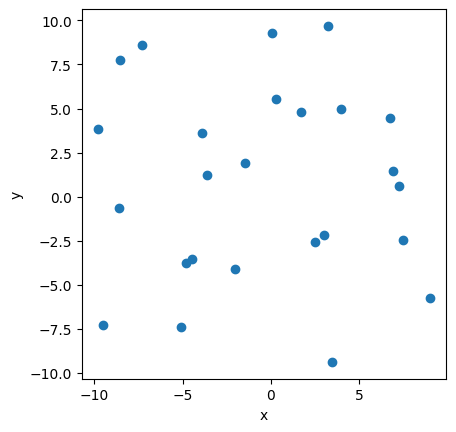

In [398]:
vis_set(points_a)

### Algorytm przyrostowy

In [399]:
def is_inside_hull(hull, point):
    a = 1
    b = len(hull)-1
    x = b//2
    while orient(hull[0], hull[a], point) == 1 and orient(hull[0], hull[b], point) == -1:
        if b == a + 1:
            break
        elif orient(hull[0], hull[a], point) == 1 and orient(hull[0], hull[x], point) == -1:
            b = x
            x = (a + b)//2
        else:
            a = x
            x = (a + b)//2
    if orient(hull[0], hull[a], point) == -1 or orient(hull[0], hull[b], point) == 1:
        return False
    if orient(hull[a], hull[b], point) == -1:
        return False
    return True
    

In [400]:
def find_left_tangent(hull, point):
    n = len(hull)
    for i in range(n-1):
        a = orient(point, hull[i-1], hull[i])
        b = orient(point, hull[i], hull[i+1])
        if a != b and (a, b) in ((1, -1), (0, -1), (1, 0)):
            return i
    a = orient(point, hull[-2], hull[-1])
    b = orient(point, hull[-1], hull[0])
    if a != b and (a, b) in ((1, -1), (0, -1), (1, 0)):
            return n-1

In [401]:
def find_right_tangent(hull, point):
    n = len(hull)
    for i in range(n-1):
        a = orient(point, hull[i-1], hull[i])
        b = orient(point, hull[i], hull[i+1])
        if a != b and (a, b) in ((-1, 1), (0, 1), (-1, 0)):
            return i
    a = orient(point, hull[-2], hull[-1])
    b = orient(point, hull[-1], hull[0])
    if a != b and (a, b) in ((-1, 1), (0, 1), (-1, 0)):
        return n-1

In [402]:
def add_point(hull, point, left, right):
    n = len(hull)
    if right-left == 1:
        hull.insert(left+1, point)
    elif left < right:
        del hull[left+1:right]
        hull.insert(left+1, point)
    else:
        del hull[left+1:]
        del hull[:right]
        hull.append(point)

In [403]:
def incremental(points):
    n = len(points)
    hull = points[:3]
    if orient(hull[0], hull[1], hull[2]) == -1:
        hull[1], hull[2] = hull[2], hull[1]
    for i in range(3, n):
        if not is_inside_hull(hull, points[i]):
            l = find_left_tangent(hull, points[i])
            r = find_right_tangent(hull, points[i])
            add_point(hull, points[i], l, r)
    return hull

In [404]:
hull_incremental = incremental(points_a)

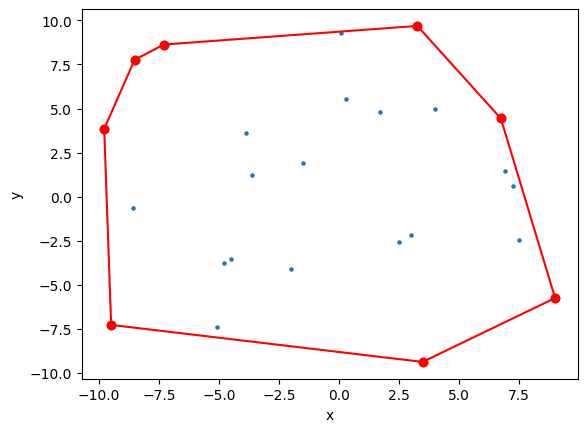

In [405]:
vis_hull_incremental(points_a, hull_incremental)

In [406]:
def incremental_vis(points):
    n = len(points)
    hull = points[:3]
    hull.sort(key=lambda x: (x[1], x[0]))
    if orient(hull[0], hull[1], hull[2]) == -1:
        hull[1], hull[2] = hull[2], hull[1]
    vis_hull_incremental(points, hull)
    for i in range(3, n):
        if not is_inside_hull(hull, points[i]):
            l = find_left_tangent(hull, points[i])
            r = find_right_tangent(hull, points[i])
            vis_hull_incremental(points, hull, points[i], True, l, r)
            add_point(hull, points[i], l, r)
            vis_hull_incremental(points, hull)
        else:
            vis_hull_incremental(points, hull, points[i], False)
    return hull

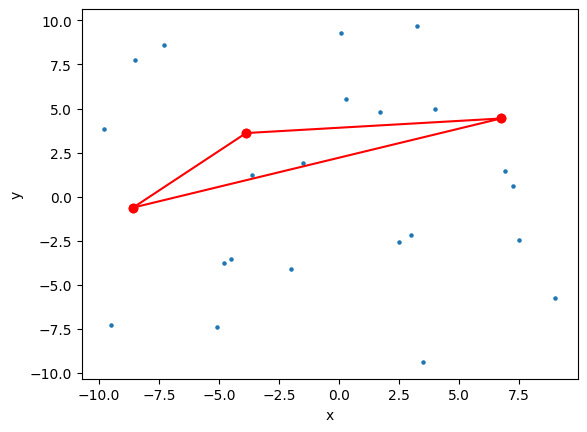

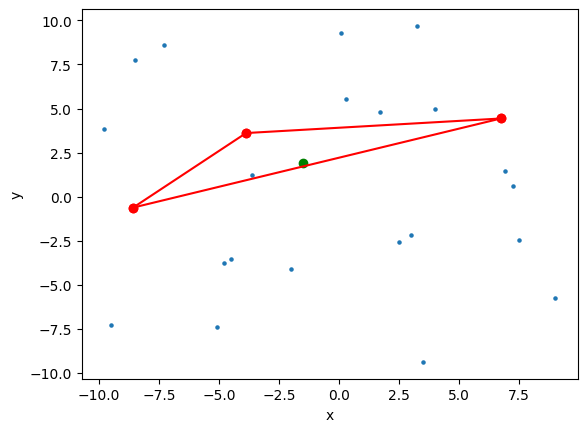

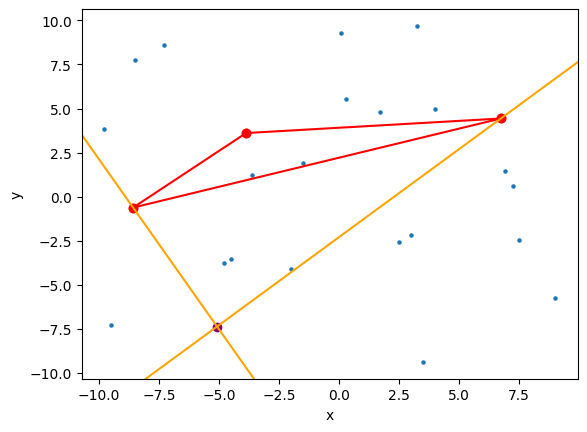

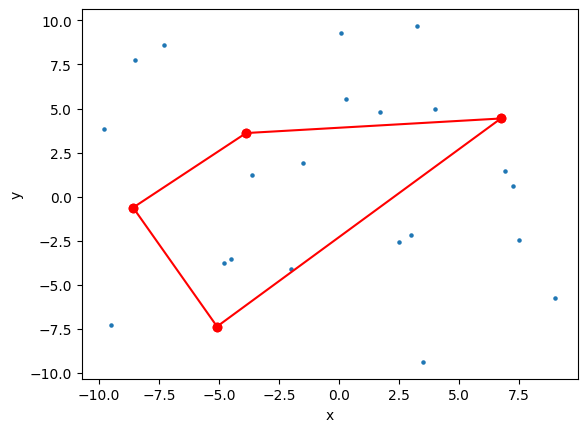

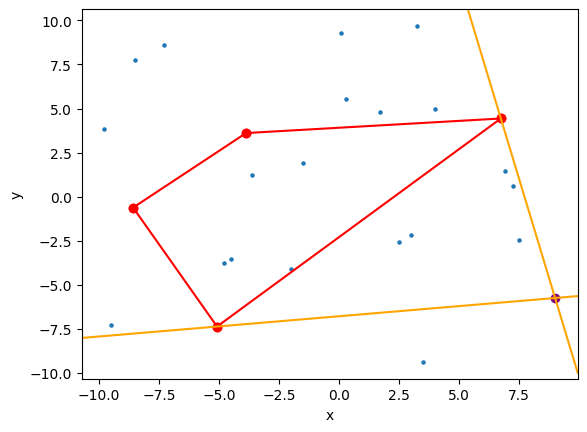

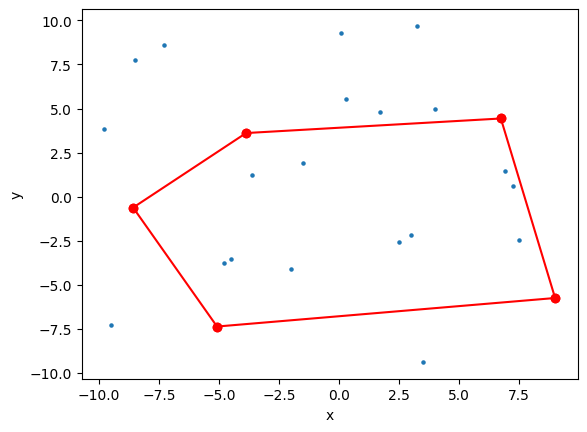

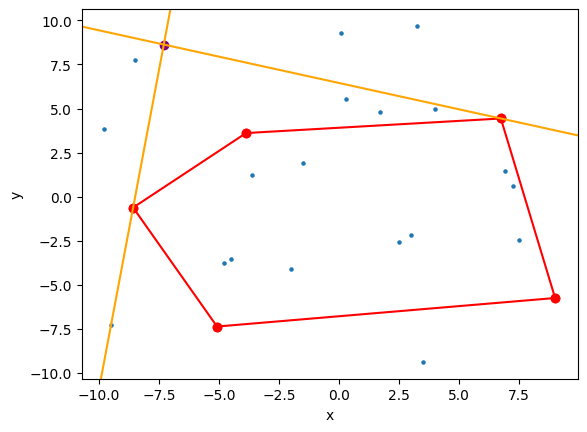

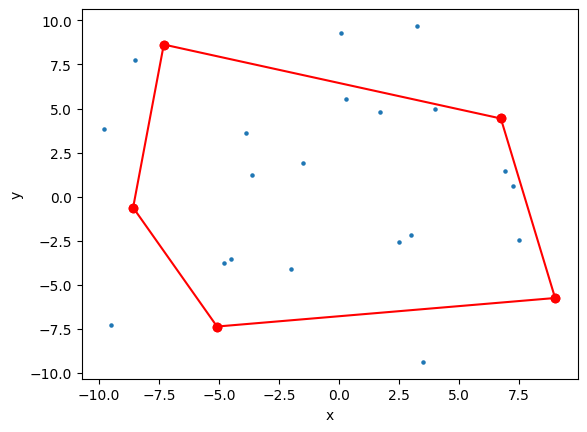

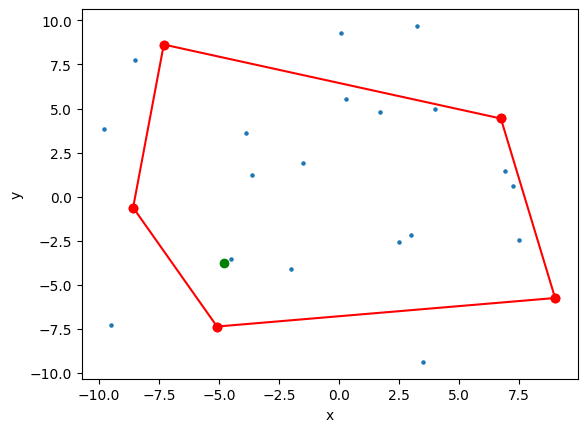

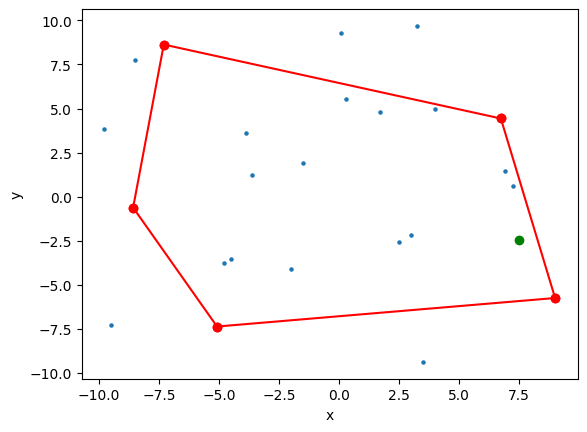

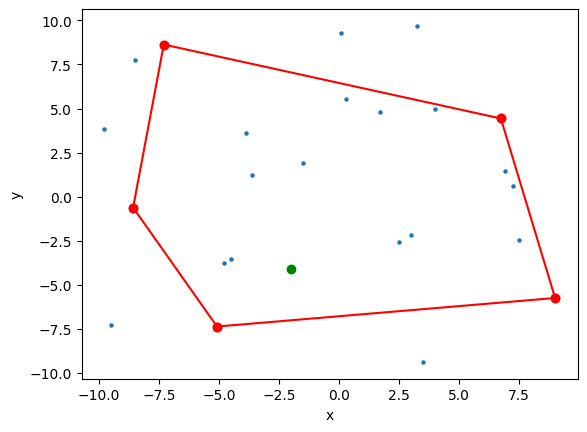

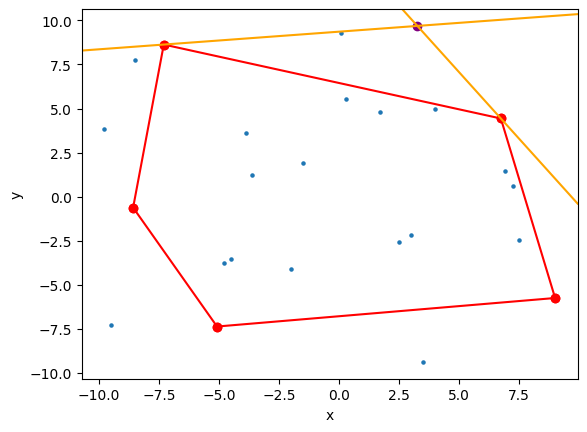

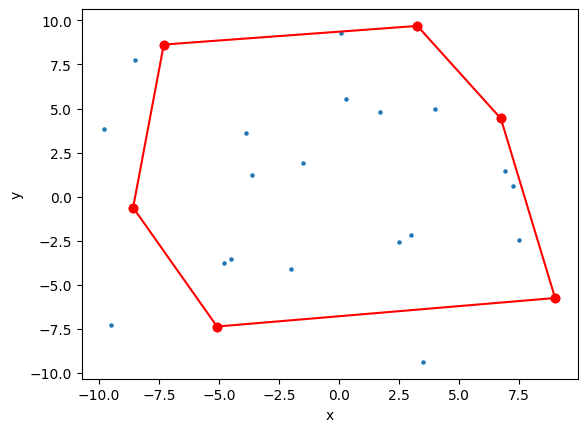

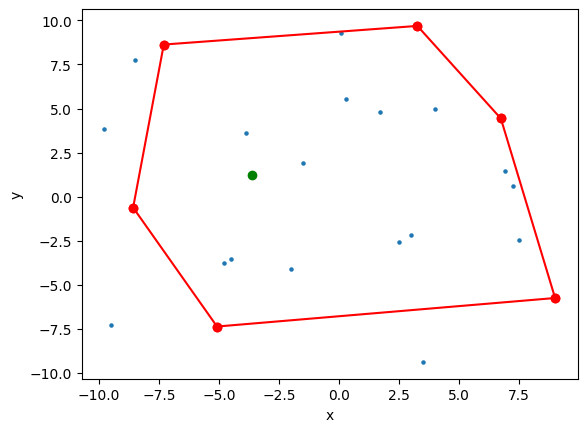

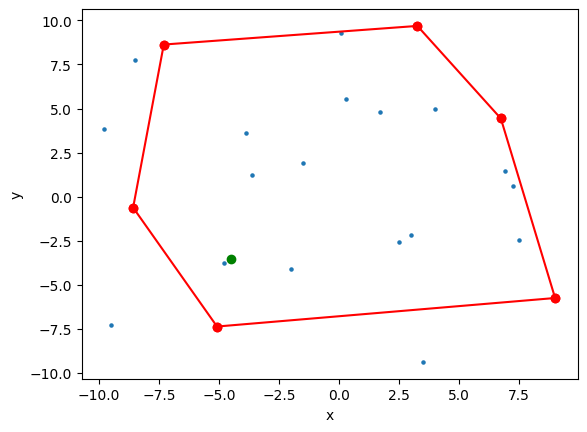

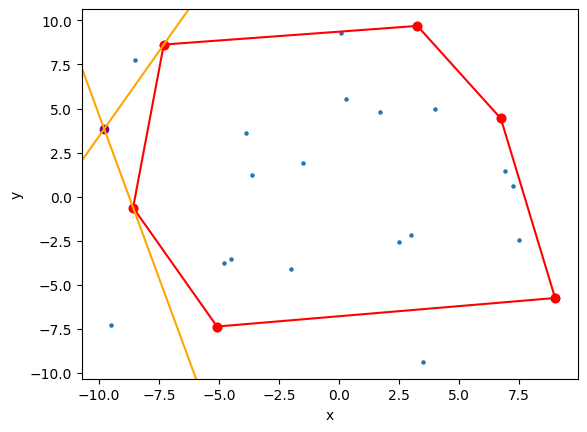

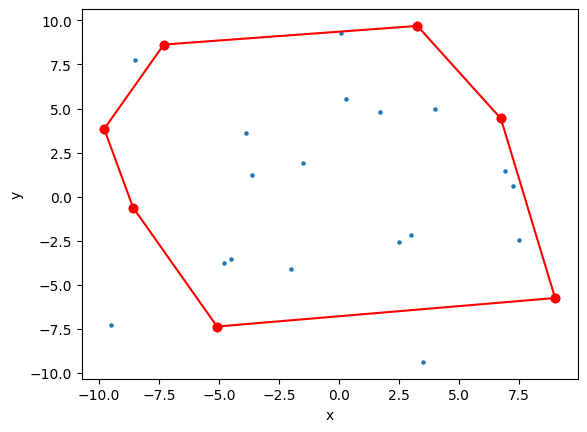

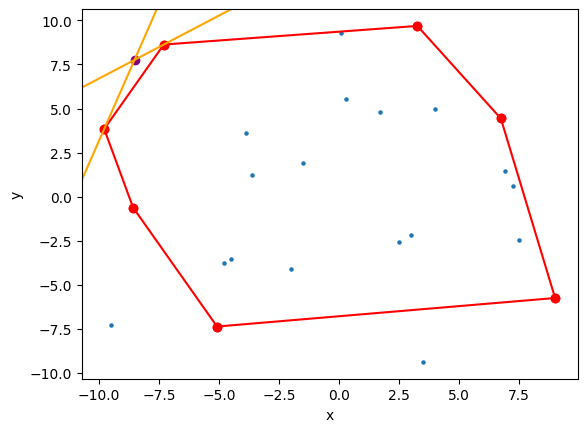

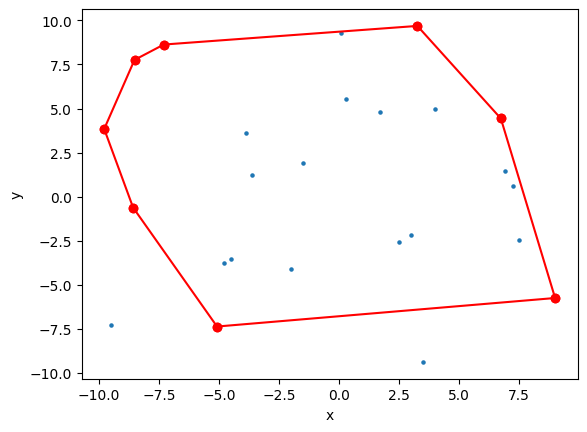

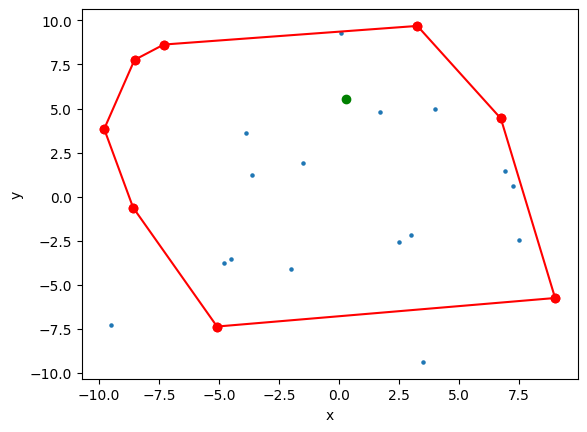

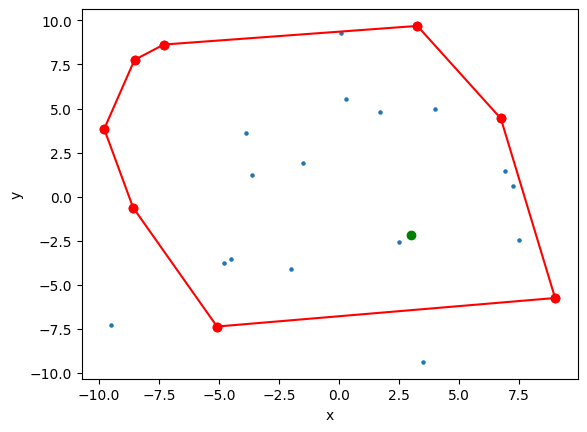

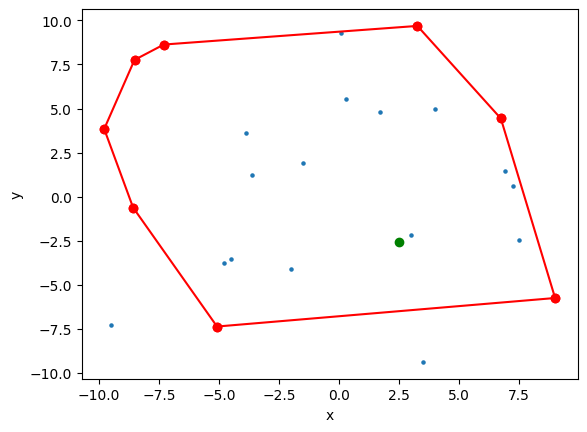

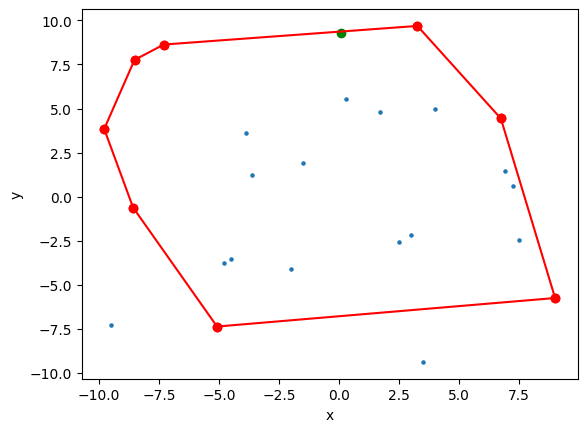

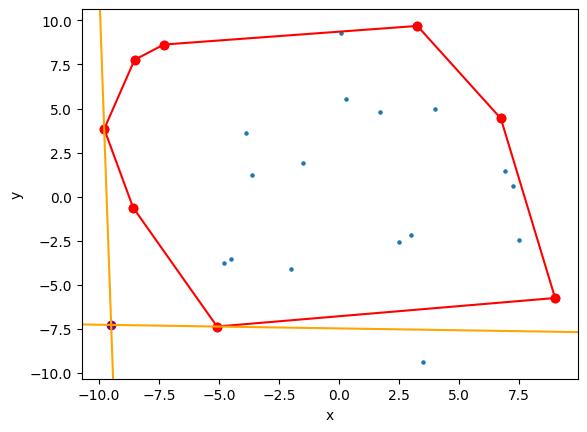

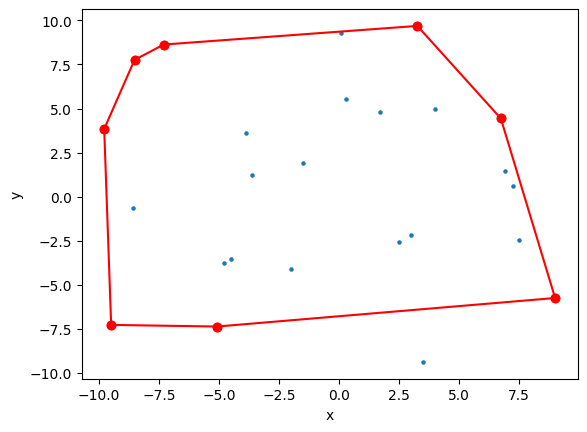

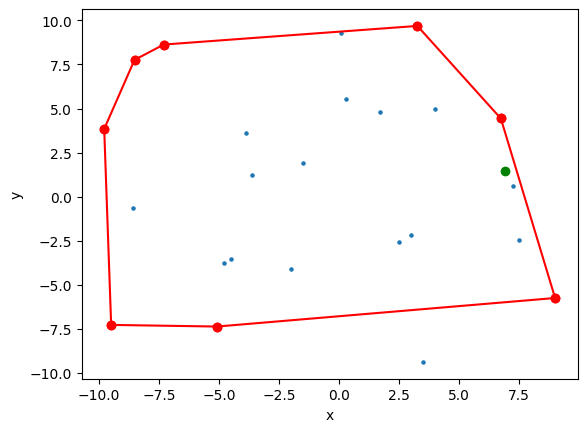

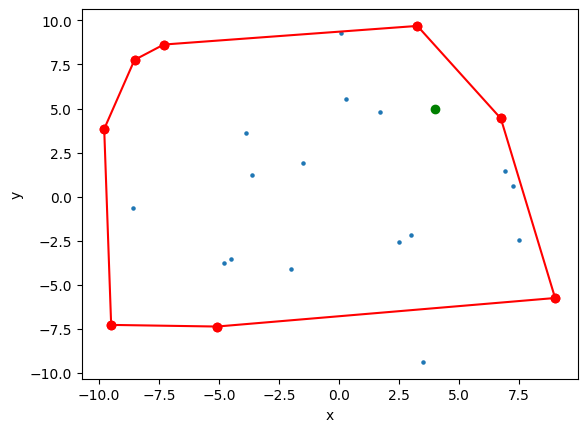

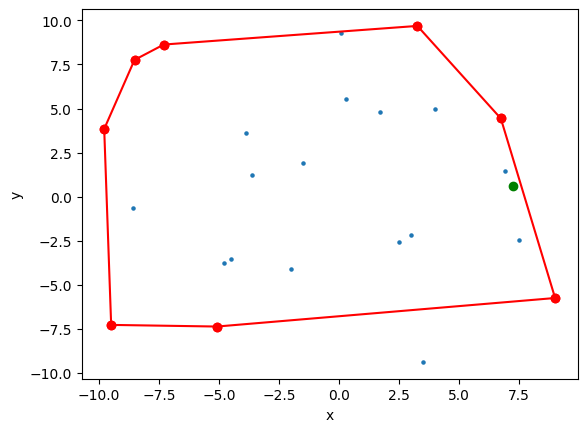

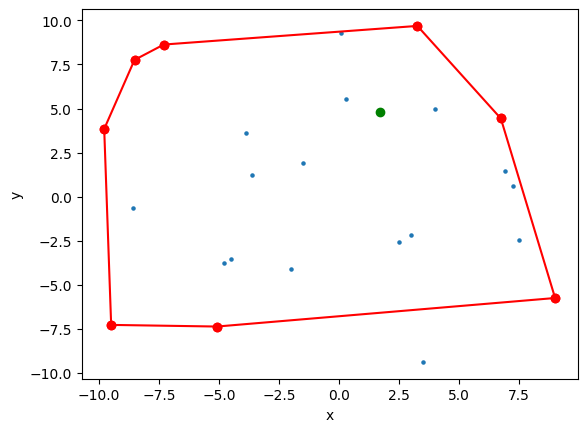

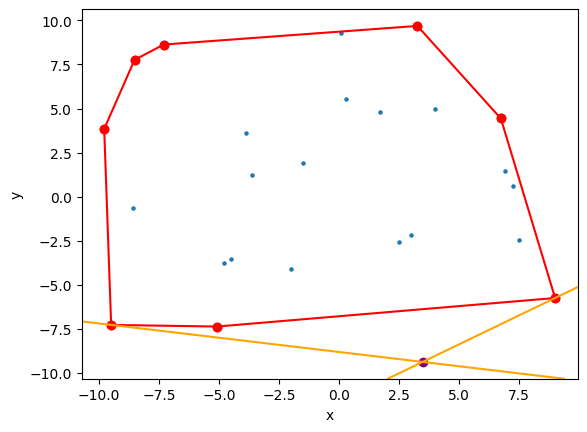

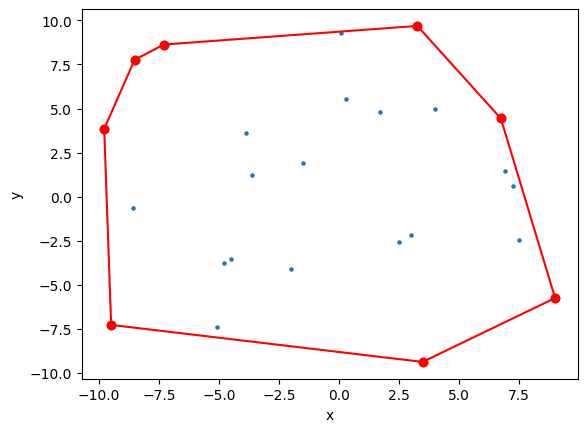

[(9.004351241228473, -5.745628044515834),
 (6.743659454559456, 4.43397078411663),
 (3.264820443849846, 9.683550006784209),
 (-7.301169755036032, 8.627398731513697),
 (-8.521453268215499, 7.755564311006662),
 (-9.784211115865673, 3.8407514658735273),
 (-9.494032707358642, -7.271238948310284),
 (3.4832861250299594, -9.370389903618225)]

In [407]:
incremental_vis(points_a)